# Deriving parameters based on radial profiles

In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from dwarfs.photometry import photometry as phot
from dwarfs.photometry import utils

### Building an isophotal profile

To derive things like concentration and half-life radius, we need a radial curve of growth.  The first step in getting these parameters is thus to determine the isophotal profile of the galaxy in question.  Below is a demonstration of how to do this using the software package included in this repository.

The example image used has been hand-masked of interloping sources, as well as one random pointlike source within the galaxy (for demonstration purposes).

In [2]:
# Read in the masked image
imarr = fits.getdata('masked.fits')

# Convert it to a masked array
maskarr = np.ma.masked_array(imarr, mask=(imarr == -999))

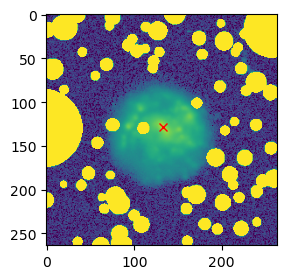

In [3]:
# Make a profile instance using the masked image
prof = phot.Profile(maskarr)

# Estimate the galaxy center
halfBoxWid = 20  # Determines the size of the box used in the center of the image for this estimate
x0, y0 = prof.initializeCenter(halfBoxWid)

# Show this on the image
lgIm = utils.ds9LogScale(maskarr)
plt.figure(figsize=(3, 3))
plt.imshow(lgIm, vmin=-3, vmax=1)
plt.plot(x0, y0, 'rx')

In [4]:
# Now fit isophotes, fixing no parameters to see what happens
ellipse = prof.initializeEllipse(x0=x0, y0=y0, sma=20, pa=0, eps=0.5)
isoList = prof.fitEllipses(ellipse)  # Using default parameters for fitter

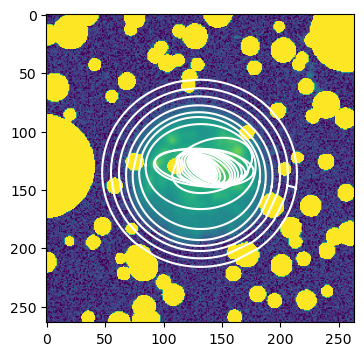

In [5]:
# Showing these on the image
plt.figure(figsize=(4, 4))
prof.visualizeEllipses(isoList, vmin=-3, vmax=1)

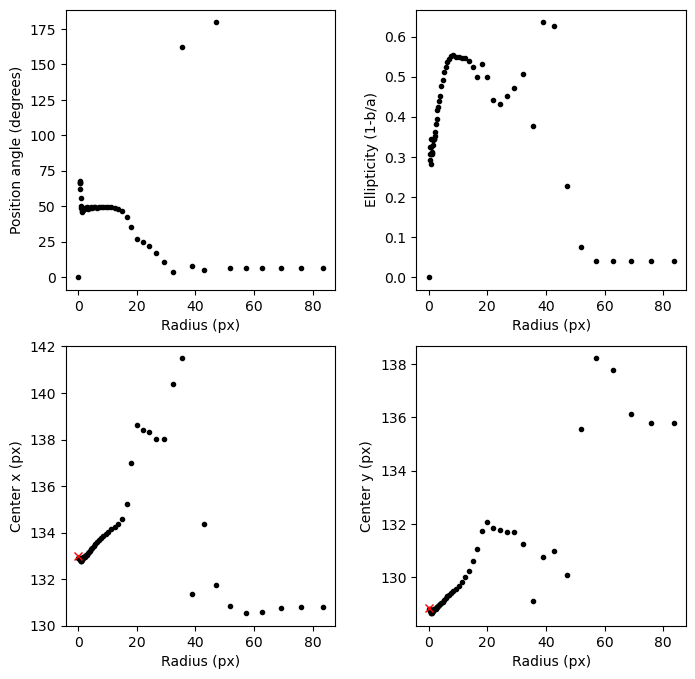

In [6]:
# Plotting some profiles
fig, ax = plt.subplots(2, 2, figsize=(8, 8))

ax[0, 0].plot(isoList.sma, np.degrees(isoList.pa), 'k.')
ax[0, 0].set_xlabel('Radius (px)')
ax[0, 0].set_ylabel('Position angle (degrees)')

ax[0, 1].plot(isoList.sma, isoList.eps, 'k.')
ax[0, 1].set_xlabel('Radius (px)')
ax[0, 1].set_ylabel('Ellipticity (1-b/a)')

ax[1, 0].plot(isoList.sma, isoList.x0, 'k.')
ax[1, 0].plot(0, x0, 'rx')  # The initial guess
ax[1, 0].set_xlabel('Radius (px)')
ax[1, 0].set_ylabel('Center x (px)')

ax[1, 1].plot(isoList.sma, isoList.y0, 'k.')
ax[1, 1].plot(0, y0, 'rx')  # The initial guess
ax[1, 1].set_xlabel('Radius (px)')
ax[1, 1].set_ylabel('Center y (px)')
plt.subplots_adjust(wspace=0.3, hspace=0.2)

Best practice when deriving a curve of growth is to keep the isophote shapes fixed, so we need some strategy to pick the best isophote parameters for this fixed shape.  For early type dwarfs, this should be straight-forward, since they should have fairly regular isophotes--maybe we pick the mean position angle and ellipticity of the whole profile, for example.  For irregular dwarfs like this one, it's harder.  Past studies have used the mean parameters derived in the far outskirts, where the profile shapes seem to converge to more constant values.  So here, for example, we can use the mean of the values beyond ~50px radius.  We'll do that for now, but evidently an automated means of picking these values is needed for the whole sample.

Doing this, we are evidently choosing a center offset from the galaxy bulge, which is probably a bad idea.

In [7]:
# Define basic parameters
want = isoList.sma > 50
x0 = np.mean(isoList.x0[want])
y0 = np.mean(isoList.y0[want])
pa = np.mean(isoList.pa[want])
eps = np.mean(isoList.eps[want])
print(x0, y0, pa, eps)

130.73421772780304 136.5480680936715 0.11201629894658138 0.04628194996367271


Now we can derive the profile using fixed parameters, which is better for things like half-light radius and concentration.  But first I'm going to interpolate the galaxy flux across the masks.  We need a noise estimate for this.

In [8]:
# Getting estimates of the background noise and sky local to the galaxy
maxRad = isoList.sma[-1]*1.5  # For noise estimate; masks galaxy out to this radius
rms, sbLim, sky = phot.measureImageNoise(maskarr, x0, y0, maxRad)
print(rms, sbLim, sky)

0.006961861882527251 0.0018239677066766188 -0.0007456770690623671


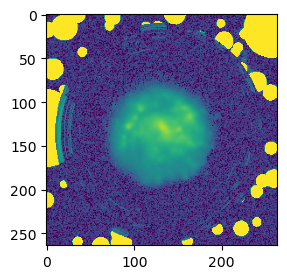

In [9]:
interparr = phot.interpolateAcrossMasks(maskarr, x0, y0, maxRad, pa, eps, rms, ampCut=0.01)

lgIm = utils.ds9LogScale(interparr)
plt.figure(figsize=(3, 3))
plt.imshow(lgIm, vmin=-3, vmax=1)

Now we redo the isophote measurements with fixed ellipses on this "unmasked" image.  We do this by exploiting the software; it has a parameter called 'maxrit', which is the maximum radius out to which to try fitting the isophote shapes.  If we set that to 1 pixel, it won't fit at all.  When doing this, though, always set a maximum radius for the profile (maxsma), or it will take a very long time to run.

I'm also going to swap to a linear spacing (fitter default is logarithmic, to enhance S/N in the outskirts), with a width of 0.5" (3 pixels), which is maybe sort of close to the seeing in this image.

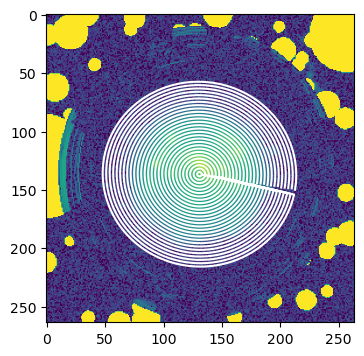

In [10]:
prof = phot.Profile(interparr)
ellipse = prof.initializeEllipse(x0=x0, y0=y0, sma=20, pa=pa, eps=eps)
isoList = prof.fitEllipses(ellipse, maxsma=isoList.sma[-1], maxrit=1, step=3, linear=True)

plt.figure(figsize=(4, 4))
prof.visualizeEllipses(isoList, vmin=-3, vmax=1)

(31.5, 22.5)

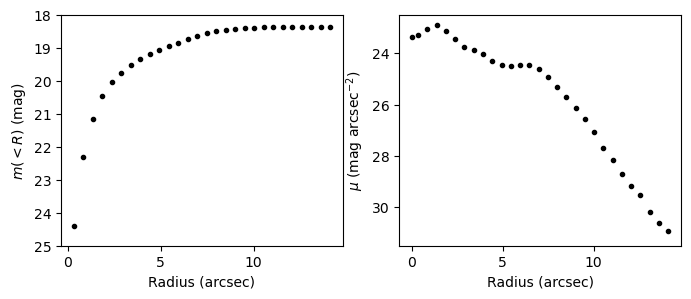

In [11]:
# Curve of growth and surface brightness profile
magZp = 27  # From HSC documentation
pxScale = 0.17
rad = isoList.sma * pxScale
mag = -2.5*np.log10(isoList.tflux_e) + magZp
sb = -2.5*np.log10(isoList.intens) + magZp + 2.5*np.log10(pxScale**2)

fig, ax = plt.subplots(1, 2, figsize=(8, 3))

ax[0].plot(rad, mag, 'k.')
ax[0].set_xlabel('Radius (arcsec)')
ax[0].set_ylabel(r'$m(<R)$ (mag)')
ax[0].set_ylim([25, 18])

ax[1].plot(rad, sb, 'k.')
ax[1].set_xlabel('Radius (arcsec)')
ax[1].set_ylabel(r'$\mu$ (mag arcsec$^{-2}$)')
ax[1].set_ylim([31.5, 22.5])

Note the rise in the center of the surface brightness profile: that's where the isophotes encounter the bulge for the first time.  The total magnitude should be insensitive to this, but other parameters might not be.

### Deriving morphological parameters from these

In [12]:
# Create an instance of a new class using the isoList
dervals = phot.DerivedValues(isoList, magZp=magZp, pxScale=pxScale)

In [13]:
# Derive curve of growth corrected for local sky (see above)
sma, cog = dervals.curveOfGrowth(sky=sky)
# Use this to derive the total magnitude
totmag = dervals.totalMagnitude(sma, cog)
print(totmag)

18.36812598354873


In [14]:
# Use this to derive other quantities
reff = dervals.fractionalRadius(totmag, fluxFrac=0.5)  # Half-light radius
c82 = dervals.concentration82(totmag)  # C82 = 5log(R80/R20)
cRe = dervals.concentrationRe(totmag)  # From Trujillo et al. (2001)
rpetro = dervals.petrosianRadius()
print('Half-light radius = %.4f arcsec' % (reff*pxScale))
print('C82 = %.4f' % (c82))
print('C (Trujillo) = %.4f' % (cRe))
print('Petrosian radius = %.4f arcsec' % (rpetro*pxScale))

Half-light radius = 4.3520 arcsec
C82 = 2.7115
C (Trujillo) = 0.6458
Petrosian radius = 1.3434 arcsec
